# Baseline Model Training & Evaluation

This notebook implements and evaluates five baseline regression models for predicting hourly traffic volume (`vehicle_count`) on Irish roads using Apache SparkML. Each model is trained on the same feature set and evaluated using consistent metrics — RMSE, MAE, and R² — enabling a fair and structured comparison across all baselines.

The models implemented are:
1. Linear Regression — simplest statistical baseline
2. Decision Tree Regressor — simple non-linear baseline
3. Random Forest Regressor — ensemble tree based baseline
4. Gradient Boosted Tree Regressor — strongest tree based baseline
5. Generalised Linear Regression — statistical distribution based baseline

All models are trained using a temporal train/test split, preserving the chronological order of the dataset to reflect a realistic traffic forecasting scenario.

## 1. Data Preparation

Before training any model, we load the final feature dataset, perform readiness checks, assemble the feature vector, and define the temporal train/test split. All five models share the same prepared dataset to ensure a fair and consistent comparison.

### 1.1 Load Final Feature Dataset

In [0]:
# Load final feature dataset
df = spark.table("traffic_features_final")

print("Table loaded         : traffic_features_final")
print("Total rows           :", f"{df.count():,}")
print("Total columns        :", len(df.columns))
print("Columns              :", df.columns)

Table loaded         : traffic_features_final
Total rows           : 7,503,913
Total columns        : 20
Columns              : ['avg_speed', 'max_speed', 'min_speed', 'speed_std', 'avg_length', 'max_length', 'length_std', 'avg_headway', 'min_headway', 'avg_gap', 'min_gap', 'month', 'day', 'hour', 'cosit', 'lane', 'day_type_index', 'speed_category_index', 'congestion_index_index', 'vehicle_count']


### 1.2 Feature Readiness Check

We verify that the final feature dataset is clean and ready for model training — checking for null values, correct data types, and reasonable value ranges across all features.

In [0]:
from pyspark.sql.functions import col, sum as spark_sum

final_features = [
    "avg_speed", "max_speed", "min_speed", "speed_std",
    "avg_length", "max_length", "length_std",
    "avg_headway", "min_headway",
    "avg_gap", "min_gap",
    "month", "day", "hour",
    "cosit", "lane",
    "day_type_index", "speed_category_index", "congestion_index_index"
]

target = "vehicle_count"

# Null check
print("Null Check:")
print(f"{'Feature':<35} {'Null Count':>12} {'Status':>10}")
print("-" * 60)
for c in final_features + [target]:
    null_count = df.filter(col(c).isNull()).count()
    status     = "CLEAN" if null_count == 0 else "NULLS"
    print(f"{c:<35} {null_count:>12,}   {status}")

# Data types
print("\nData Types:")
print(f"{'Feature':<35} {'Type':>10}")
print("-" * 48)
for field in df.schema.fields:
    if field.name in final_features + [target]:
        print(f"{field.name:<35} {str(field.dataType):>10}")

# Value ranges
print("\nValue Ranges:")
print(f"{'Feature':<35} {'Min':>12} {'Max':>12}")
print("-" * 62)
for c in final_features + [target]:
    min_val = df.selectExpr(f"min({c})").first()[0]
    max_val = df.selectExpr(f"max({c})").first()[0]
    print(f"{c:<35} {str(round(min_val,2)):>12} {str(round(max_val,2)):>12}")

Null Check:
Feature                               Null Count     Status
------------------------------------------------------------
avg_speed                                      0   CLEAN
max_speed                                      0   CLEAN
min_speed                                      0   CLEAN
speed_std                                      0   CLEAN
avg_length                                     0   CLEAN
max_length                                     0   CLEAN
length_std                                     0   CLEAN
avg_headway                                    0   CLEAN
min_headway                                    0   CLEAN
avg_gap                                        0   CLEAN
min_gap                                        0   CLEAN
month                                          0   CLEAN
day                                            0   CLEAN
hour                                           0   CLEAN
cosit                                          0   CLEAN
lane        

### 1.3 Feature Assembly

All 19 features are assembled into a single feature vector using SparkML VectorAssembler, as required by all SparkML model implementations.

In [0]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=final_features, outputCol="features")
df_assembled = assembler.transform(df).select("features", "vehicle_count", "month")

print("Feature vector assembled successfully")
print("Total rows :", f"{df_assembled.count():,}")

Feature vector assembled successfully
Total rows : 7,503,913


### 1.4 Temporal Train/Test Split

Unlike random splitting, a temporal split preserves the chronological order of the dataset — a critical requirement for time-aware traffic forecasting. Training on future data to predict the past would constitute data leakage in a time series context.

We train on the first 9 months of 2019 (January to September) and test on the remaining 3 months (October to December), reflecting a realistic scenario where a model trained on historical data is used to forecast future traffic volumes.

| Split | Months | Purpose |
|---|---|---|
| Training set | January — September (months 1—9) | Model training |
| Test set | October — December (months 10—12) | Model evaluation |

In [0]:
# Temporal split — train on months 1-9, test on months 10-12
train_df = df_assembled.filter(col("month") <= 9)
test_df  = df_assembled.filter(col("month") > 9)

print("Temporal Train/Test Split:")
print(f"  Training rows (Jan-Sep) : {train_df.count():,}")
print(f"  Test rows    (Oct-Dec)  : {test_df.count():,}")
print(f"  Train ratio             : {train_df.count()/df_assembled.count()*100:.1f}%")
print(f"  Test ratio              : {test_df.count()/df_assembled.count()*100:.1f}%")

Temporal Train/Test Split:
  Training rows (Jan-Sep) : 5,955,667
  Test rows    (Oct-Dec)  : 1,548,246
  Train ratio             : 79.4%
  Test ratio              : 20.6%


## 2. Linear Regression

Linear Regression is the simplest and most interpretable baseline model. It assumes a linear relationship between the input features and the target variable `vehicle_count`. While traffic data is inherently non-linear, Linear Regression serves as an important reference point — any more complex model should outperform it to justify the added complexity.

### 2.1 Model Training

In [0]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="vehicle_count",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)

print("Training Linear Regression...")
lr_model = lr.fit(train_df)
print("Training complete")

Training Linear Regression...
Training complete


### 2.2 Predictions & Evaluation

In [0]:
from pyspark.ml.evaluation import RegressionEvaluator

# Predictions
lr_predictions = lr_model.transform(test_df)

# Metrics
evaluator_rmse = RegressionEvaluator(labelCol="vehicle_count", predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol="vehicle_count", predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol="vehicle_count", predictionCol="prediction", metricName="r2")

lr_rmse = evaluator_rmse.evaluate(lr_predictions)
lr_mae  = evaluator_mae.evaluate(lr_predictions)
lr_r2   = evaluator_r2.evaluate(lr_predictions)

print("Linear Regression — Evaluation Metrics:")
print("-" * 40)
print(f"  RMSE : {round(lr_rmse, 4)}")
print(f"  MAE  : {round(lr_mae, 4)}")
print(f"  R²   : {round(lr_r2, 4)}")

Linear Regression — Evaluation Metrics:
----------------------------------------
  RMSE : 231.8707
  MAE  : 166.7146
  R²   : 0.574


### 2.3 Residual Plot

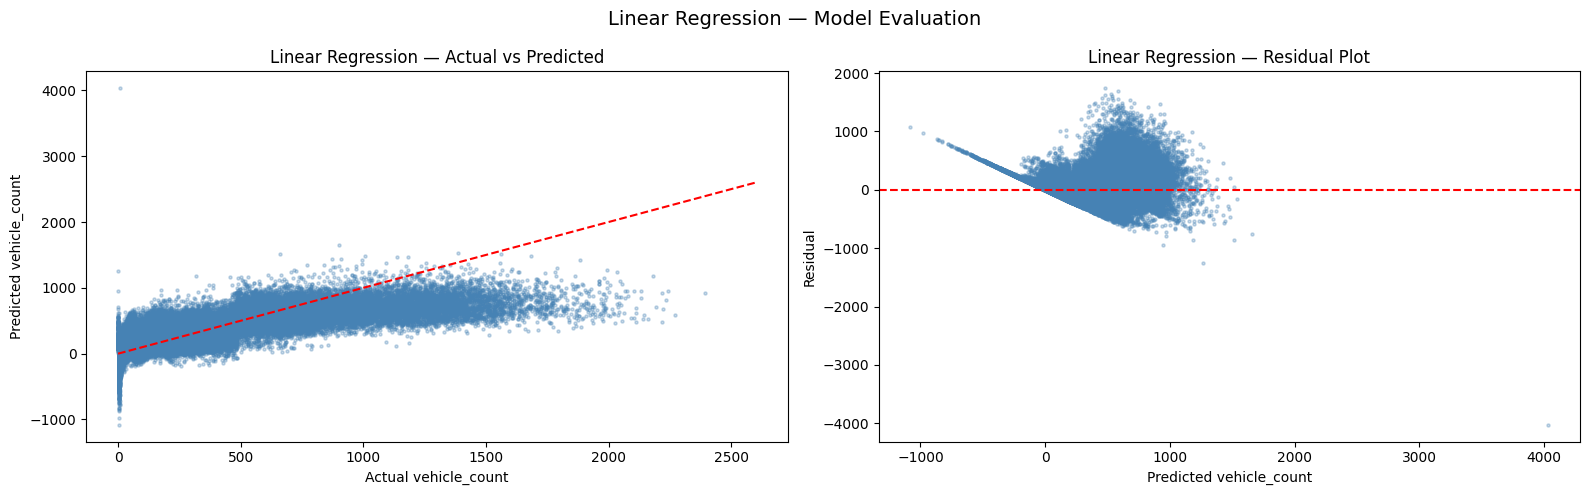

In [0]:
import matplotlib.pyplot as plt

# Sample for plotting
lr_sample = lr_predictions.select("vehicle_count", "prediction") \
                           .sample(fraction=0.05, seed=42).toPandas()

lr_sample["residual"] = lr_sample["vehicle_count"] - lr_sample["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Actual vs Predicted
axes[0].scatter(lr_sample["vehicle_count"], lr_sample["prediction"],
                alpha=0.3, color="steelblue", s=5)
axes[0].plot([0, 2600], [0, 2600], color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Linear Regression — Actual vs Predicted")
axes[0].set_xlabel("Actual vehicle_count")
axes[0].set_ylabel("Predicted vehicle_count")

# Residual plot
axes[1].scatter(lr_sample["prediction"], lr_sample["residual"],
                alpha=0.3, color="steelblue", s=5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Linear Regression — Residual Plot")
axes[1].set_xlabel("Predicted vehicle_count")
axes[1].set_ylabel("Residual")

plt.suptitle("Linear Regression — Model Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Decision Tree Regressor

Decision Tree Regressor is a simple non-linear baseline that partitions the feature space into regions using a series of binary splits. Unlike Linear Regression, it can capture non-linear relationships and feature interactions — making it more suited to traffic data where relationships between features and volume are rarely linear. It also provides interpretable feature importance scores.

### 3.1 Model Training

In [0]:
from pyspark.ml.regression import DecisionTreeRegressor

dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="vehicle_count",
    maxDepth=8,
    seed=42
)

print("Training Decision Tree Regressor...")
dt_model = dt.fit(train_df)
print("Training complete")

Training Decision Tree Regressor...
Training complete


### 3.2 Predictions & Evaluation

In [0]:
dt_predictions = dt_model.transform(test_df)

dt_rmse = evaluator_rmse.evaluate(dt_predictions)
dt_mae  = evaluator_mae.evaluate(dt_predictions)
dt_r2   = evaluator_r2.evaluate(dt_predictions)

print("Decision Tree Regressor — Evaluation Metrics:")
print("-" * 40)
print(f"  RMSE : {round(dt_rmse, 4)}")
print(f"  MAE  : {round(dt_mae, 4)}")
print(f"  R²   : {round(dt_r2, 4)}")

Decision Tree Regressor — Evaluation Metrics:
----------------------------------------
  RMSE : 47.0032
  MAE  : 19.5844
  R²   : 0.9825


### 3.3 Actual vs Predicted & Feature Importance

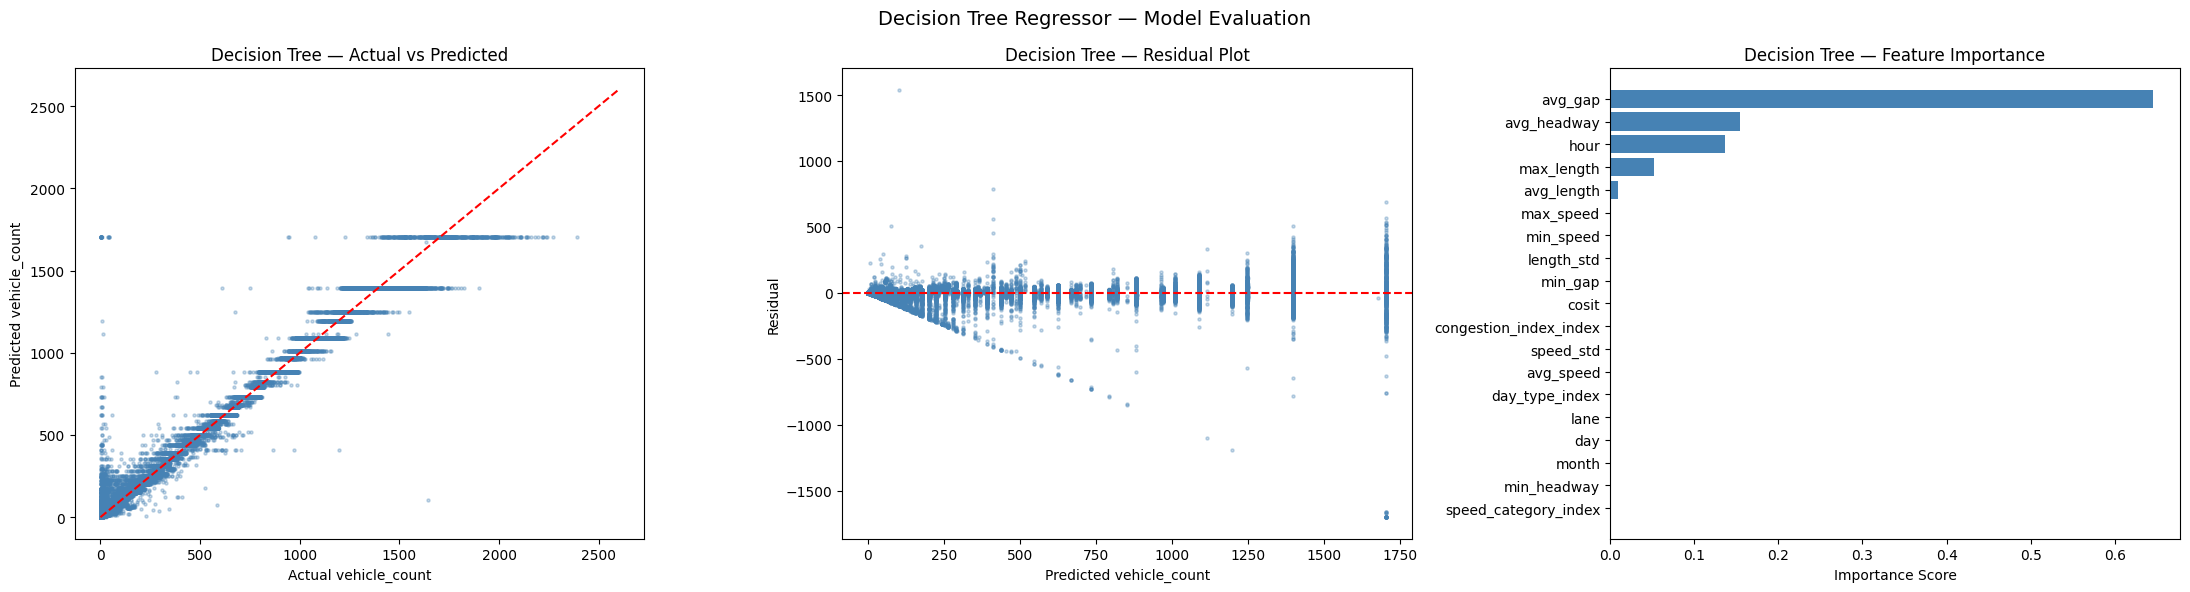

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

dt_sample = dt_predictions.select("vehicle_count", "prediction") \
                           .sample(fraction=0.05, seed=42).toPandas()

dt_sample["residual"] = dt_sample["vehicle_count"] - dt_sample["prediction"]

importance_scores = dt_model.featureImportances.toArray()
importance_pdf    = pd.DataFrame({
    "Feature"   : final_features,
    "Importance": importance_scores
}).sort_values("Importance", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(dt_sample["vehicle_count"], dt_sample["prediction"],
                alpha=0.3, color="steelblue", s=5)
axes[0].plot([0, 2600], [0, 2600], color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Decision Tree — Actual vs Predicted")
axes[0].set_xlabel("Actual vehicle_count")
axes[0].set_ylabel("Predicted vehicle_count")

axes[1].scatter(dt_sample["prediction"], dt_sample["residual"],
                alpha=0.3, color="steelblue", s=5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Decision Tree — Residual Plot")
axes[1].set_xlabel("Predicted vehicle_count")
axes[1].set_ylabel("Residual")

axes[2].barh(importance_pdf["Feature"][::-1],
             importance_pdf["Importance"][::-1],
             color="steelblue", edgecolor="none")
axes[2].set_title("Decision Tree — Feature Importance")
axes[2].set_xlabel("Importance Score")

plt.suptitle("Decision Tree Regressor — Model Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Random Forest Regressor

Random Forest is an ensemble method that builds multiple decision trees and averages their predictions, reducing overfitting and improving generalisation compared to a single Decision Tree. By aggregating predictions across 50 trees, Random Forest reduces variance and is expected to produce more stable and accurate results than the single Decision Tree baseline.

### 4.1 Model Training

In [0]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="vehicle_count",
    numTrees=50,
    maxDepth=8,
    seed=42
)

print("Training Random Forest Regressor...")
rf_model = rf.fit(train_df)
print("Training complete")

Training Random Forest Regressor...
Training complete


### 4.2 Predictions & Evaluation

In [0]:
rf_predictions = rf_model.transform(test_df)

rf_rmse = evaluator_rmse.evaluate(rf_predictions)
rf_mae  = evaluator_mae.evaluate(rf_predictions)
rf_r2   = evaluator_r2.evaluate(rf_predictions)

print("Random Forest Regressor — Evaluation Metrics:")
print("-" * 40)
print(f"  RMSE : {round(rf_rmse, 4)}")
print(f"  MAE  : {round(rf_mae, 4)}")
print(f"  R²   : {round(rf_r2, 4)}")

Random Forest Regressor — Evaluation Metrics:
----------------------------------------
  RMSE : 43.8486
  MAE  : 19.8082
  R²   : 0.9848


### 4.3 Actual vs Predicted & Feature Importance

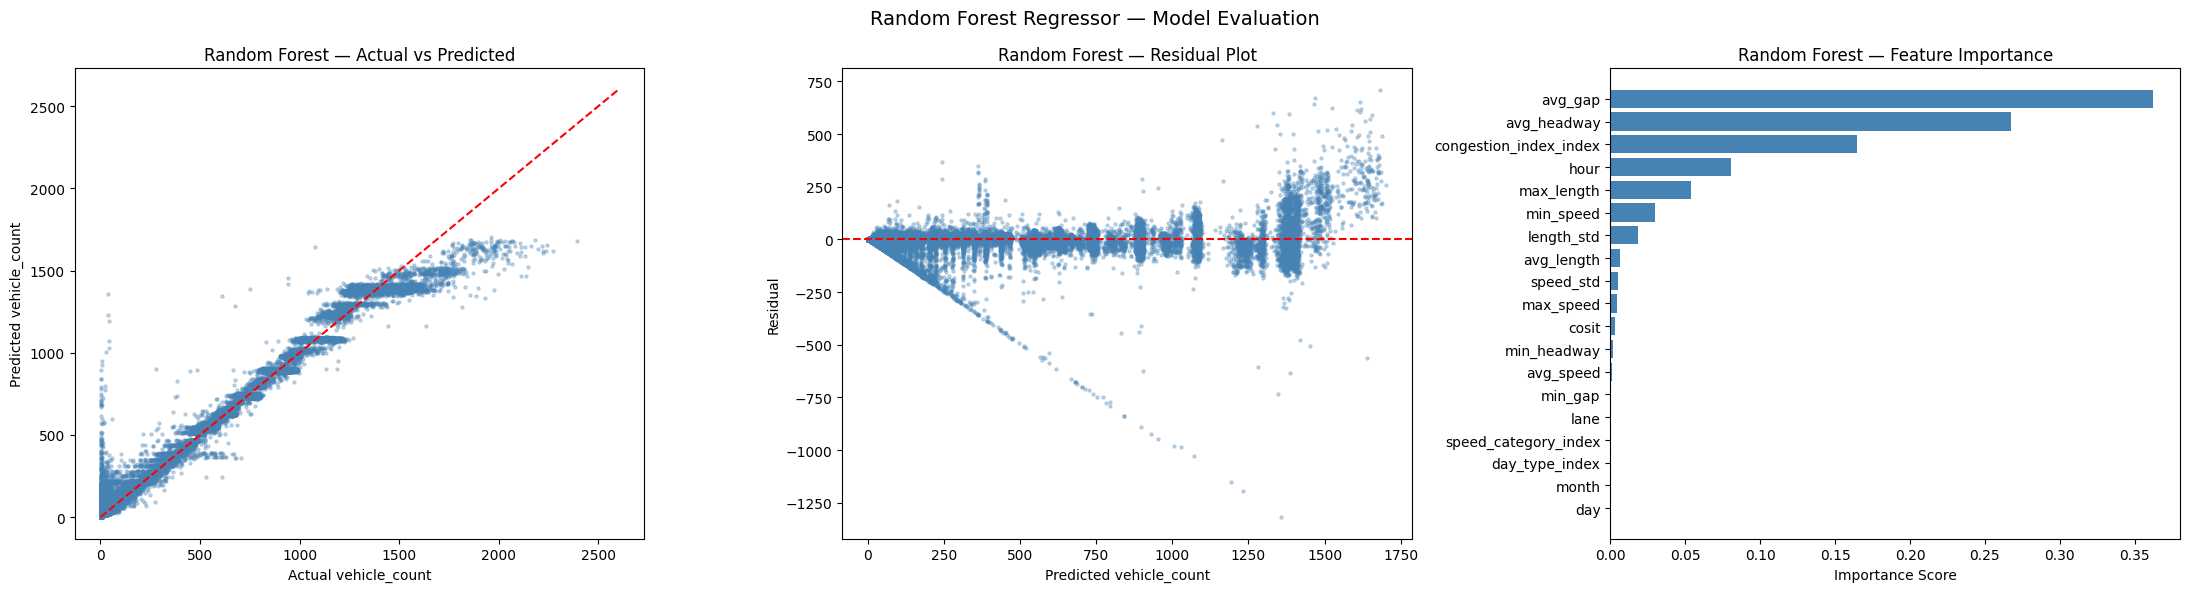

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

rf_sample = rf_predictions.select("vehicle_count", "prediction") \
                           .sample(fraction=0.05, seed=42).toPandas()

rf_sample["residual"] = rf_sample["vehicle_count"] - rf_sample["prediction"]

importance_scores = rf_model.featureImportances.toArray()
importance_pdf    = pd.DataFrame({
    "Feature"   : final_features,
    "Importance": importance_scores
}).sort_values("Importance", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(rf_sample["vehicle_count"], rf_sample["prediction"],
                alpha=0.3, color="steelblue", s=5)
axes[0].plot([0, 2600], [0, 2600], color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Random Forest — Actual vs Predicted")
axes[0].set_xlabel("Actual vehicle_count")
axes[0].set_ylabel("Predicted vehicle_count")

axes[1].scatter(rf_sample["prediction"], rf_sample["residual"],
                alpha=0.3, color="steelblue", s=5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Random Forest — Residual Plot")
axes[1].set_xlabel("Predicted vehicle_count")
axes[1].set_ylabel("Residual")

axes[2].barh(importance_pdf["Feature"][::-1],
             importance_pdf["Importance"][::-1],
             color="steelblue", edgecolor="none")
axes[2].set_title("Random Forest — Feature Importance")
axes[2].set_xlabel("Importance Score")

plt.suptitle("Random Forest Regressor — Model Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Gradient Boosted Tree Regressor

Gradient Boosted Trees (GBT) is the most powerful tree based baseline model. Unlike Random Forest which builds trees in parallel, GBT builds trees sequentially — each tree correcting the errors of the previous one. This sequential error correction makes GBT particularly effective at capturing complex patterns in traffic data, at the cost of longer training time.

### 5.1 Model Training

In [0]:
from pyspark.ml.regression import GBTRegressor

gbt = GBTRegressor(
    featuresCol="features",
    labelCol="vehicle_count",
    maxIter=50,
    maxDepth=8,
    seed=42
)

print("Training Gradient Boosted Tree Regressor...")
gbt_model = gbt.fit(train_df)
print("Training complete")

Training Gradient Boosted Tree Regressor...
Training complete


### 5.2 Predictions & Evaluation

In [0]:
gbt_predictions = gbt_model.transform(test_df)

gbt_rmse = evaluator_rmse.evaluate(gbt_predictions)
gbt_mae  = evaluator_mae.evaluate(gbt_predictions)
gbt_r2   = evaluator_r2.evaluate(gbt_predictions)

print("Gradient Boosted Tree Regressor — Evaluation Metrics:")
print("-" * 40)
print(f"  RMSE : {round(gbt_rmse, 4)}")
print(f"  MAE  : {round(gbt_mae, 4)}")
print(f"  R²   : {round(gbt_r2, 4)}")

Gradient Boosted Tree Regressor — Evaluation Metrics:
----------------------------------------
  RMSE : 30.6304
  MAE  : 15.5446
  R²   : 0.9926


### 5.3 Actual vs Predicted & Feature Importance

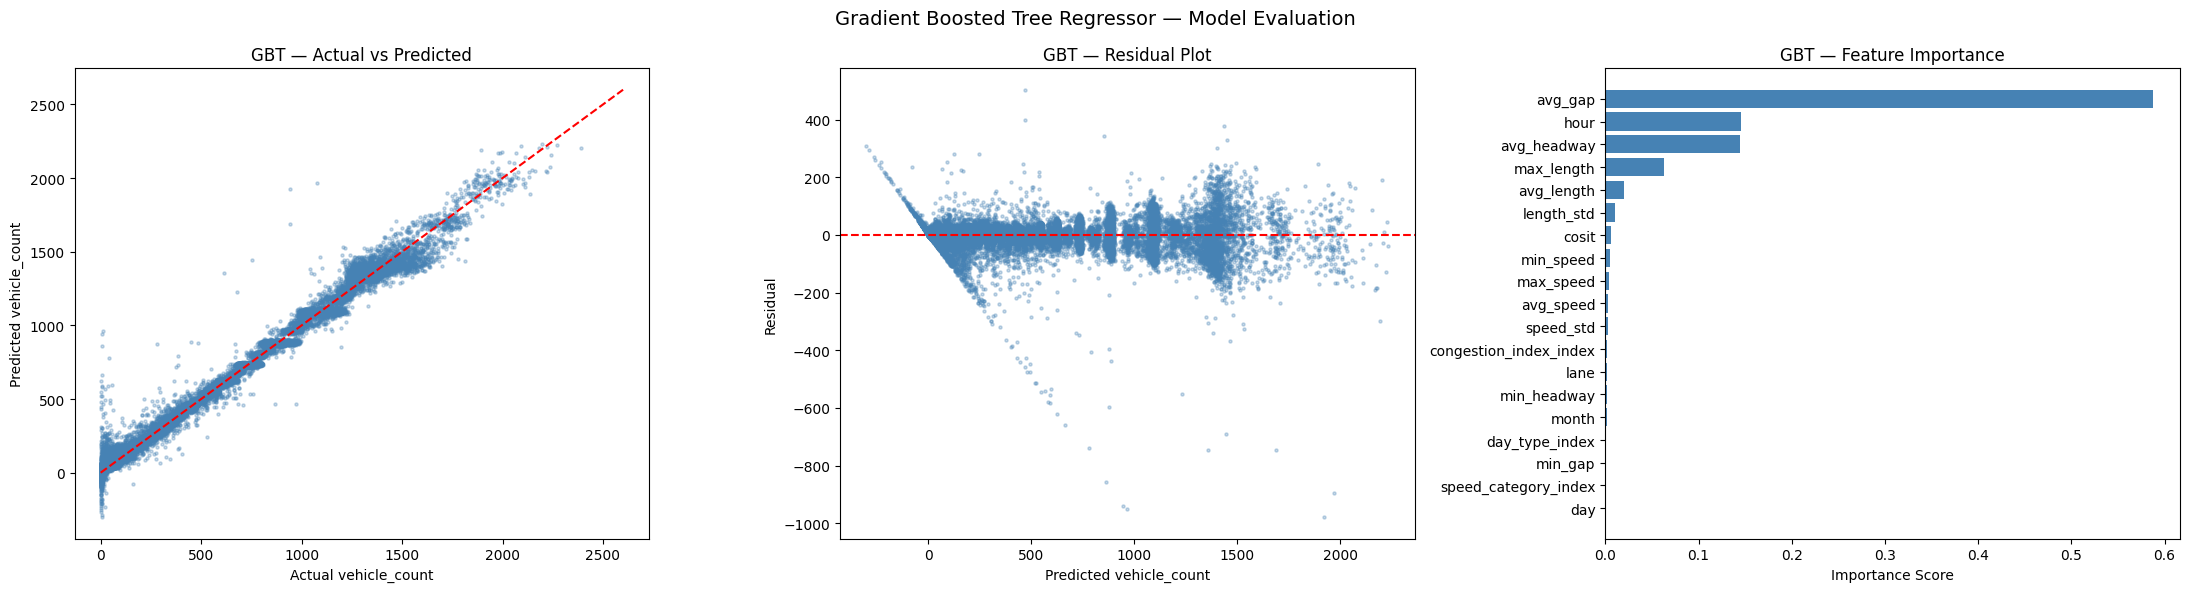

In [0]:
import matplotlib.pyplot as plt
import pandas as pd

gbt_sample = gbt_predictions.select("vehicle_count", "prediction") \
                             .sample(fraction=0.05, seed=42).toPandas()

gbt_sample["residual"] = gbt_sample["vehicle_count"] - gbt_sample["prediction"]

importance_scores = gbt_model.featureImportances.toArray()
importance_pdf    = pd.DataFrame({
    "Feature"   : final_features,
    "Importance": importance_scores
}).sort_values("Importance", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].scatter(gbt_sample["vehicle_count"], gbt_sample["prediction"],
                alpha=0.3, color="steelblue", s=5)
axes[0].plot([0, 2600], [0, 2600], color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("GBT — Actual vs Predicted")
axes[0].set_xlabel("Actual vehicle_count")
axes[0].set_ylabel("Predicted vehicle_count")

axes[1].scatter(gbt_sample["prediction"], gbt_sample["residual"],
                alpha=0.3, color="steelblue", s=5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("GBT — Residual Plot")
axes[1].set_xlabel("Predicted vehicle_count")
axes[1].set_ylabel("Residual")

axes[2].barh(importance_pdf["Feature"][::-1],
             importance_pdf["Importance"][::-1],
             color="steelblue", edgecolor="none")
axes[2].set_title("GBT — Feature Importance")
axes[2].set_xlabel("Importance Score")

plt.suptitle("Gradient Boosted Tree Regressor — Model Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Generalised Linear Regression

Generalised Linear Regression (GLR) extends standard Linear Regression by allowing the target variable to follow different statistical distributions beyond the normal distribution. For traffic count data which is non-negative and right skewed, we apply GLR with a Gaussian family and log link function — better suited to the distribution of `vehicle_count` than standard Linear Regression.

### 6.1 Model Training

In [0]:
from pyspark.ml.regression import GeneralizedLinearRegression

glr = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="vehicle_count",
    family="gaussian",
    link="log",
    maxIter=100,
    regParam=0.1
)

print("Training Generalised Linear Regression...")
glr_model = glr.fit(train_df)
print("Training complete")

Training Generalised Linear Regression...
Training complete


### 6.2 Predictions & Evaluation

In [0]:
glr_predictions = glr_model.transform(test_df)

glr_rmse = evaluator_rmse.evaluate(glr_predictions)
glr_mae  = evaluator_mae.evaluate(glr_predictions)
glr_r2   = evaluator_r2.evaluate(glr_predictions)

print("Generalised Linear Regression — Evaluation Metrics:")
print("-" * 40)
print(f"  RMSE : {round(glr_rmse, 4)}")
print(f"  MAE  : {round(glr_mae, 4)}")
print(f"  R²   : {round(glr_r2, 4)}")

Generalised Linear Regression — Evaluation Metrics:
----------------------------------------
  RMSE : 150.1206
  MAE  : 85.1184
  R²   : 0.8214


### 6.3 Actual vs Predicted & Residual Plot

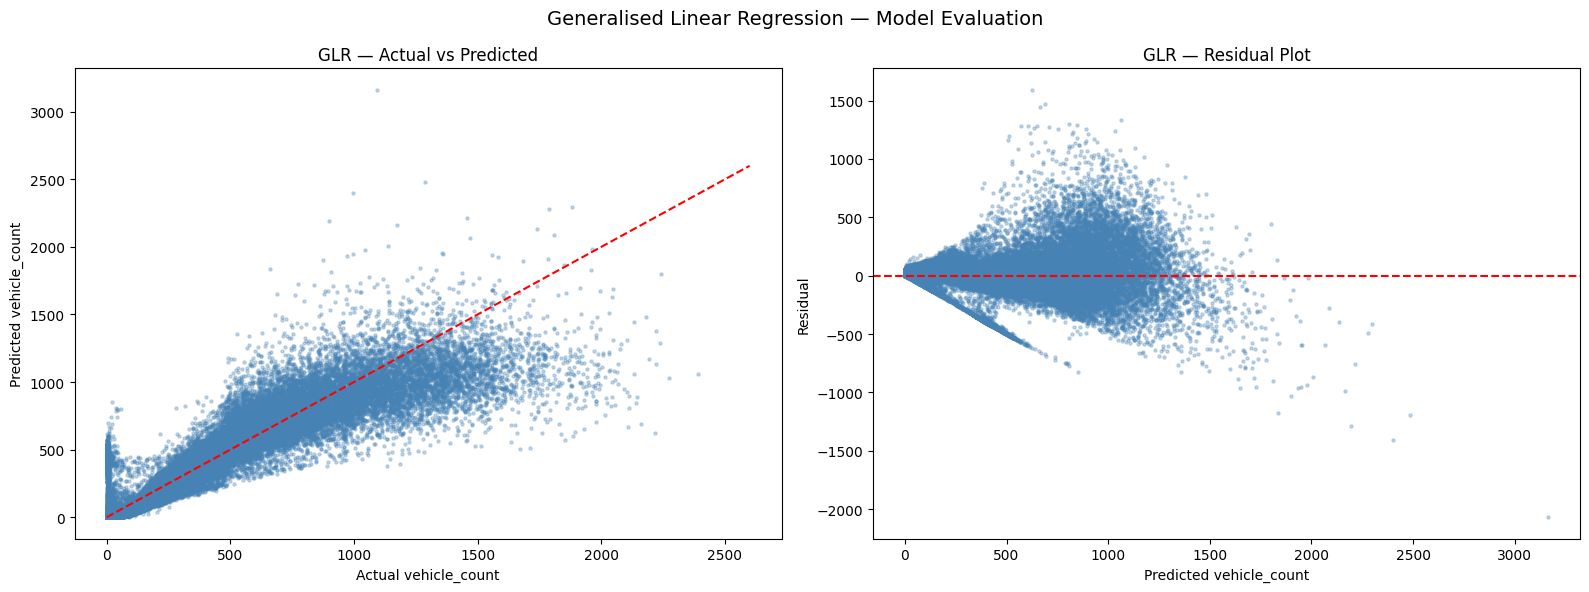

In [0]:
import matplotlib.pyplot as plt

glr_sample = glr_predictions.select("vehicle_count", "prediction") \
                             .sample(fraction=0.05, seed=42).toPandas()

glr_sample["residual"] = glr_sample["vehicle_count"] - glr_sample["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(glr_sample["vehicle_count"], glr_sample["prediction"],
                alpha=0.3, color="steelblue", s=5)
axes[0].plot([0, 2600], [0, 2600], color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("GLR — Actual vs Predicted")
axes[0].set_xlabel("Actual vehicle_count")
axes[0].set_ylabel("Predicted vehicle_count")

axes[1].scatter(glr_sample["prediction"], glr_sample["residual"],
                alpha=0.3, color="steelblue", s=5)
axes[1].axhline(y=0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("GLR — Residual Plot")
axes[1].set_xlabel("Predicted vehicle_count")
axes[1].set_ylabel("Residual")

plt.suptitle("Generalised Linear Regression — Model Evaluation", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Baseline Model Comparison

We consolidate the evaluation metrics across all five baseline models to identify the best performing approach and establish a clear performance hierarchy. All models were trained and evaluated on the same temporal split and feature set, ensuring a fair and consistent comparison.

In [0]:
import pandas as pd

results = {
    "Model": [
        "Linear Regression",
        "Generalised Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosted Tree"
    ],
    "RMSE": [lr_rmse, glr_rmse, dt_rmse, rf_rmse, gbt_rmse],
    "MAE" : [lr_mae,  glr_mae,  dt_mae,  rf_mae,  gbt_mae],
    "R²"  : [lr_r2,   glr_r2,   dt_r2,   rf_r2,   gbt_r2]
}

results_pdf = pd.DataFrame(results)
results_pdf["RMSE"] = results_pdf["RMSE"].round(4)
results_pdf["MAE"]  = results_pdf["MAE"].round(4)
results_pdf["R²"]   = results_pdf["R²"].round(4)
results_pdf         = results_pdf.sort_values("R²", ascending=False).reset_index(drop=True)
results_pdf.index  += 1

display(results_pdf)

Model,RMSE,MAE,R²
Gradient Boosted Tree,30.6304,15.5446,0.9926
Random Forest,43.8486,19.8082,0.9848
Decision Tree,47.0032,19.5844,0.9825
Generalised Linear Regression,150.1206,85.1184,0.8214
Linear Regression,231.8707,166.7146,0.574


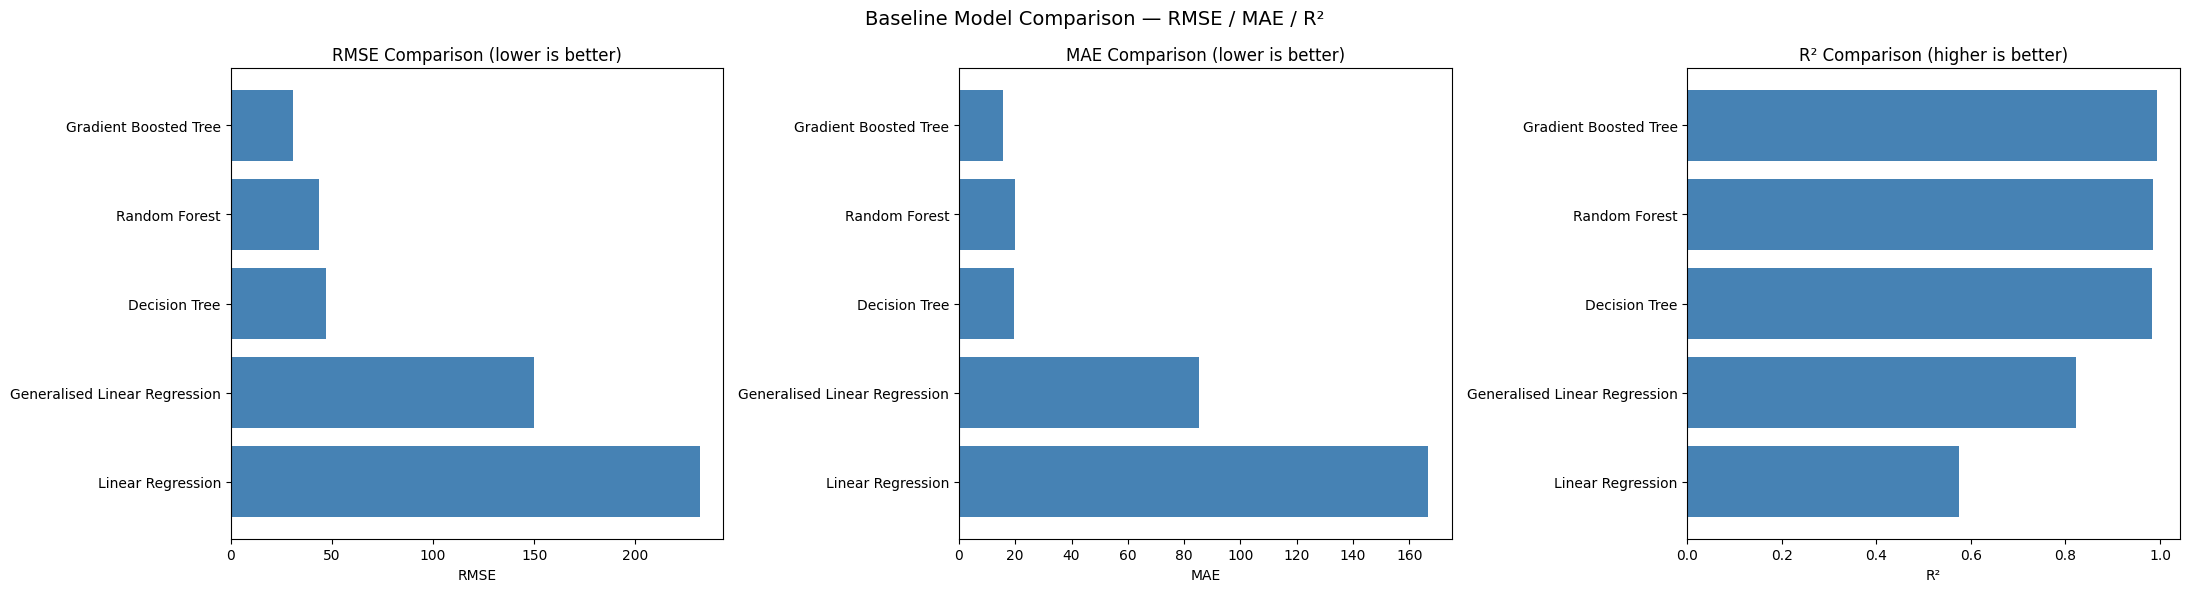

In [0]:
import matplotlib.pyplot as plt
import numpy as np

models = results_pdf["Model"].tolist()
rmse   = results_pdf["RMSE"].tolist()
mae    = results_pdf["MAE"].tolist()
r2     = results_pdf["R²"].tolist()

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# RMSE
axes[0].barh(models, rmse, color="steelblue", edgecolor="none")
axes[0].set_title("RMSE Comparison (lower is better)")
axes[0].set_xlabel("RMSE")
axes[0].invert_yaxis()

# MAE
axes[1].barh(models, mae, color="steelblue", edgecolor="none")
axes[1].set_title("MAE Comparison (lower is better)")
axes[1].set_xlabel("MAE")
axes[1].invert_yaxis()

# R²
axes[2].barh(models, r2, color="steelblue", edgecolor="none")
axes[2].set_title("R² Comparison (higher is better)")
axes[2].set_xlabel("R²")
axes[2].invert_yaxis()

plt.suptitle("Baseline Model Comparison — RMSE / MAE / R²", fontsize=14)
plt.tight_layout()
plt.show()

### 7.1 Discussion

The baseline comparison reveals a clear performance hierarchy across the five models:

**Gradient Boosted Tree** emerges as the strongest baseline with an R² of 0.9926 and RMSE of 30.63 — outperforming all other models across every metric. Its sequential error correction mechanism allows it to capture the complex non-linear patterns inherent in hourly traffic data.

**Random Forest** and **Decision Tree** both perform strongly with R² values of 0.9848 and 0.9825 respectively, confirming that tree based models are well suited to this dataset.

**Generalised Linear Regression** achieves a moderate R² of 0.8214, significantly outperforming standard Linear Regression by accounting for the non-normal distribution of vehicle counts.

**Linear Regression** performs the weakest with R² of 0.574, confirming that the relationship between traffic features and vehicle count is inherently non-linear and cannot be adequately captured by a linear model.

Based on these results, **Gradient Boosted Tree** is selected as the best performing baseline and will be taken forward for hyperparameter tuning and optimisation in the next notebook.